<!-- [intro-a] -->
# Project Demo — Architecture Overview

A map of how `dialectica` actually fits together: corpus in, retrieval strategies, the MCP
server that serves them, and the two different agents that consume them. Breadth first — no
internals here. For the mechanics behind the MCP bridge specifically (closures, schema
passthrough, client re-entrancy), see `02-mcp-bridge-internals.ipynb`.

<!-- [A-a] -->
## A — The big picture

One PDF becomes four different ways to retrieve from it, served over MCP, and consumed by two
separate agents that don't use them the same way.

<!-- [A.1a] -->
```mermaid
flowchart LR
    PDF[("PDF corpus")] --> ING["ingest.py<br/>load_corpus()"]
    ING --> RET["retrieve.py<br/>Retrieval class"]

    subgraph STRAT["4 retrieval strategies"]
        direction TB
        P["parent_retriever"]
        S["make_search_self_query()"]
        B["make_bm_25_retriever()"]
        E["make_ensemble_retriever()"]
    end

    RET --> STRAT
    STRAT -->|"@mcp.tool"| SRV["mcp_tools.py<br/>MCP server, HTTP"]

    SRV -->|"MCP protocol"| GRAPH["agent.py<br/>reflection graph"]
    SRV -->|"MCP protocol"| DEMO["mcp_tools.py<br/>demo tool-calling agent"]

    GRAPH --> ANS1["answer"]
    DEMO --> ANS2["answer"]
```

<!-- [A.2a] -->
Notice the fork at the bottom: the same four tools reach two different agents that use them
differently. That asymmetry is real, not an oversight — section D looks at it directly.

<!-- [B-a] -->
## B — Module map

Four files, four jobs. Each diagram box above is one of these.

<!-- [B.1a] -->
| file | job |
|---|---|
| `ingest.py` | PDF -> `list[Document]`, one `Document` per chapter, split along the PDF's own outline |
| `retrieve.py` | `Retrieval` class: builds the Chroma vector store + parent docstore, exposes the 4 retrieval strategies |
| `mcp_tools.py` | wraps those 4 strategies as `@mcp.tool`s, serves them over HTTP, bridges them into LangChain `StructuredTool`s |
| `agent.py` | LangGraph reflection loop (`retriever -> composer -> reflect`); `retriever` now calls the MCP server instead of `Retrieval` directly |

<!-- [C-a] -->
## C — The MCP / OpenAI round trip

Two different destinations, four round trips, every time the agent answers a question with a
tool. This is flow, not mechanism — *why* each step works is `02-mcp-bridge-internals.ipynb`'s
job.

<!-- [C.1a] -->
```mermaid
sequenceDiagram
    participant App as LangChain agent
    participant MCP as MCP server (127.0.0.1:8931)
    participant AI as OpenAI API

    App->>MCP: list_tools()
    MCP-->>App: tool specs (name, description, input_schema)
    App->>AI: send message + tool specs
    AI-->>App: "call call_parent_retriever(query=...)"
    App->>MCP: call_tool("call_parent_retriever", {...})
    MCP-->>App: result.data (retrieved text)
    App->>AI: send tool result
    AI-->>App: final answer
```

<!-- [C.2a] -->
Two separate wire formats end up compatible by coincidence, not design — both MCP and OpenAI's
tool-calling API want JSON Schema, so the same dict survives both trips untouched. See
`02-mcp-bridge-internals.ipynb`, section C, for how that was actually verified.

<!-- [D-a] -->
## D — Two agents, one server

Same four tools, two different relationships to them.

<!-- [D.1a] -->
| | `agent.py`'s reflection graph | `mcp_tools.py`'s demo agent |
|---|---|---|
| which tool(s) | always `call_parent_retriever` | LLM picks among all 4 |
| who decides | hardcoded in `retriever` | `create_agent`'s model, per query |
| loop | explicit: retrieve -> compose -> reflect -> maybe retry | none — one tool call, one answer |
| purpose | the actual application | verification that the bridge works |

/Users/marcelohanones/Developer/personal/IBM-RAG-and-Agentic-AI/.venv/lib/python3.12/site-packages/pypdf/_crypt_providers/_cryptography.py:32: CryptographyDeprecationWarning: ARC4 has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.ARC4 and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  from cryptography.hazmat.primitives.ciphers.algorithms import AES, ARC4


parent and child matches vector_store and docstore
nothing loaded


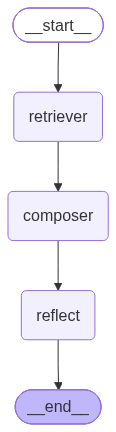

In [1]:
# [D.2a]
# Ground truth, not hand-drawn — regenerates from the real compiled graph.
# Importing ParallelProse.agent triggers the real retrieval build (mcp_tools.py's module-level
# side effect), so this takes a moment the first time.
from IPython.display import Image

from ParallelProse.agent import reflection_app

Image(reflection_app.get_graph().draw_mermaid_png())

<!-- [D.3a] -->
Same table, as a decision point. In `agent.py`, every diamond is Python code — even the one
downstream of `reflect`, whose condition (`needs_revision`, `narrowed_query`) is LLM output. In
the demo agent, the diamond sits inside the model itself.

```mermaid
flowchart TB
    subgraph FIXED["agent.py — code decides"]
        direction TB
        S1(["START"]) --> R1["retriever"]
        R1 --> C1["composer"]
        C1 --> RF1["reflect"]
        RF1 -.->|"LLM fills: needs_revision?\nnarrowed_query?"| D1{"Python if/else\n(route_after_reflection)"}
        D1 -->|"no, or max iters"| E1(["END"])
        D1 -->|"yes + narrowed_query"| R1
        D1 -->|"yes, no narrowed_query"| C1
    end

    subgraph AGENTIC["demo agent — model decides"]
        direction TB
        Q(["query"]) --> M["LLM (create_agent)"]
        M -->|"decides"| T{"call a tool?"}
        T -->|"yes — picks 1 of 4"| TOOL["MCP tool"]
        TOOL --> M
        T -->|"no"| A2(["answer"])
    end
```

<!-- [D.4a] -->
`retriever` running over MCP instead of a direct function call doesn't move it from FIXED to
AGENTIC — it's still reached by a hardcoded edge (`START -> retriever`) and never had the option
not to run. MCP only changed *how* the call reaches the retrieval logic (HTTP to a tool server
instead of an in-process function); it didn't move the decision of *whether to call it at all*
into the model. That move is what the demo agent's diamond shows.

<!-- [E-a] -->
## E — Where the knobs are

For swapping corpora or tweaking behavior, these are the actual points of control.

<!-- [E.1a] -->
| knob | where | controls |
|---|---|---|
| `PDF_PATH` | `ingest.py` | which corpus gets loaded |
| `collection_name` | `Retrieval(...)` in `mcp_tools.py` | which persisted Chroma collection gets read/written — the only place this now happens, since `agent.py` no longer builds its own |
| which `@mcp.tool` gets called | `retriever` in `agent.py`, or the query given to the demo agent | which of the 4 retrieval strategies actually runs |
| `MAX_ITERATIONS` | `agent.py` | how many reflect -> retry cycles are allowed before giving up |
| `child_config` / `parent_config` | `Retrieval.__init__` in `retrieve.py` | chunk sizes for the parent/child splitters |

<!-- [close-a] -->
Next: `02-mcp-bridge-internals.ipynb` — the mechanics behind section C's round trip, verified
live with a debugger during the session this notebook was built from.